In [22]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style settings — all charts render inline, no files saved
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

# Load dataset
df = pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')

print(" Data Loaded Successfully")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

 Data Loaded Successfully
Shape: (9800, 18)

Columns:
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [23]:
# Data Cleaning & Preparation

# Parse dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  dayfirst=True)

# Extract time features
df['Year']       = df['Order_Date'].dt.year
df['Month']      = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
df['Quarter']    = df['Order_Date'].dt.to_period('Q').astype(str)
df['Week']       = df['Order_Date'].dt.isocalendar().week.astype(int)

# Shipping time (days)
df['Ship_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# Fill missing postal codes
df['Postal_Code'] = df['Postal_Code'].fillna(0).astype(int)

# Remove duplicate rows if any
df.drop_duplicates(inplace=True)

print(" Cleaning Done")
print(f"\nDate Range : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
print(f"Duplicates : 0 (removed)")
print(f"Missing    : {df.isnull().sum().sum()} remaining")
print(f"\nSample of new columns:")
df[['Order_Date','Year','Month_Name','Quarter','Ship_Days']].head(3)

 Cleaning Done

Date Range : 2015-01-03 → 2018-12-30
Duplicates : 0 (removed)
Missing    : 0 remaining

Sample of new columns:


,Order_Date,Year,Month_Name,Quarter,Ship_Days
0,2017-11-08,2017,Nov,2017Q4,3
1,2017-11-08,2017,Nov,2017Q4,3
2,2017-06-12,2017,Jun,2017Q2,4


In [24]:
#  KPI Summary

total_revenue   = df['Sales'].sum()
total_orders    = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
aov             = total_revenue / total_orders          # average order aalue
avg_ship_days   = df['Ship_Days'].mean()
total_products  = df['Product_Name'].nunique()

kpis = {
    ' Total Revenue'      : f"${total_revenue:,.0f}",
    ' Total Orders'       : f"{total_orders:,}",
    ' Unique Customers'   : f"{total_customers:,}",
    ' Avg Order Value'    : f"${aov:,.2f}",
    ' Avg Shipping Days'  : f"{avg_ship_days:.1f} days",
    ' Unique Products'   : f"{total_products:,}",
}


print("         KEY PERFORMANCE INDICATORS")
for k, v in kpis.items():
    print(f"  {k:<28} {v}")


         KEY PERFORMANCE INDICATORS
   Total Revenue               $2,261,537
   Total Orders                4,922
   Unique Customers            793
   Avg Order Value             $459.48
   Avg Shipping Days           4.0 days
   Unique Products             1,849


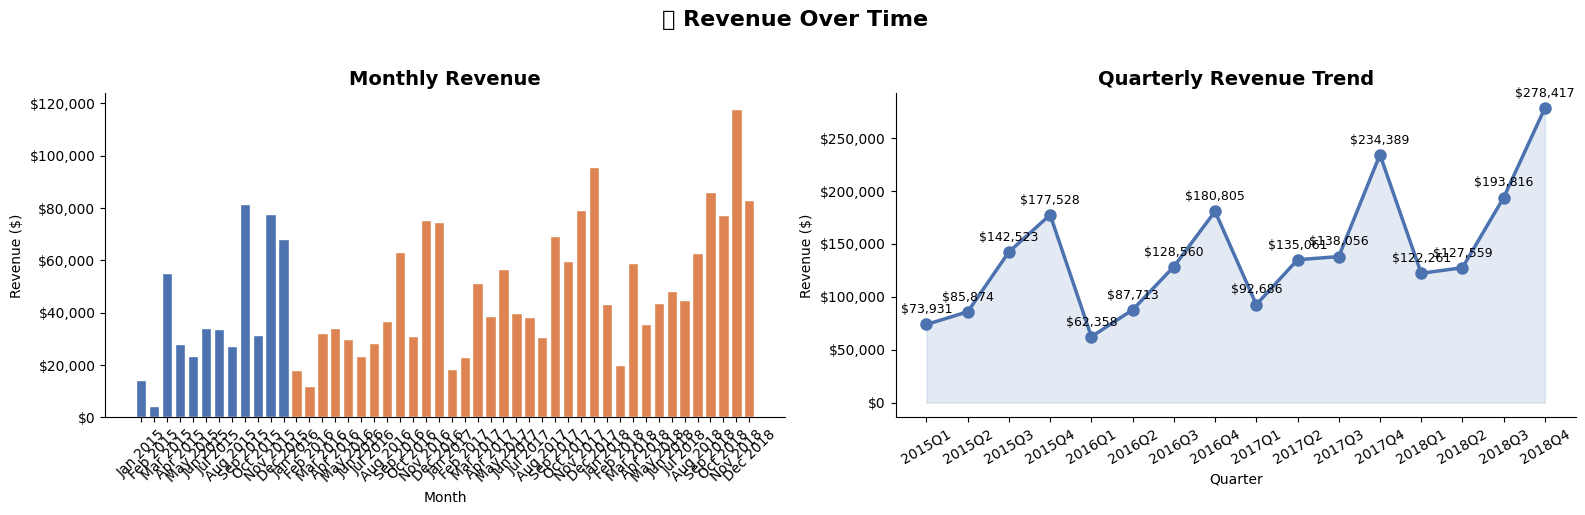

In [25]:
# Revenue Trend Over Time

monthly = (df.groupby(['Year', 'Month', 'Month_Name'])['Sales']
             .sum()
             .reset_index()
             .sort_values(['Year', 'Month']))

monthly['Label'] = monthly['Month_Name'] + ' ' + monthly['Year'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Monthly Revenue Bar
colors = ['#4C72B0' if y == monthly['Year'].min() else '#DD8452'
          for y in monthly['Year']]
axes[0].bar(monthly['Label'], monthly['Sales'], color=colors, edgecolor='white')
axes[0].set_title('Monthly Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# ── Chart 2: Quarterly Revenue Line
quarterly = df.groupby('Quarter')['Sales'].sum().reset_index()
axes[1].plot(quarterly['Quarter'], quarterly['Sales'],
             marker='o', linewidth=2.5, color='#4C72B0', markersize=8)
axes[1].fill_between(quarterly['Quarter'], quarterly['Sales'], alpha=0.15, color='#4C72B0')
for i, row in quarterly.iterrows():
    axes[1].annotate(f"${row['Sales']:,.0f}",
                     (row['Quarter'], row['Sales']),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
axes[1].set_title('Quarterly Revenue Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('📅 Revenue Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

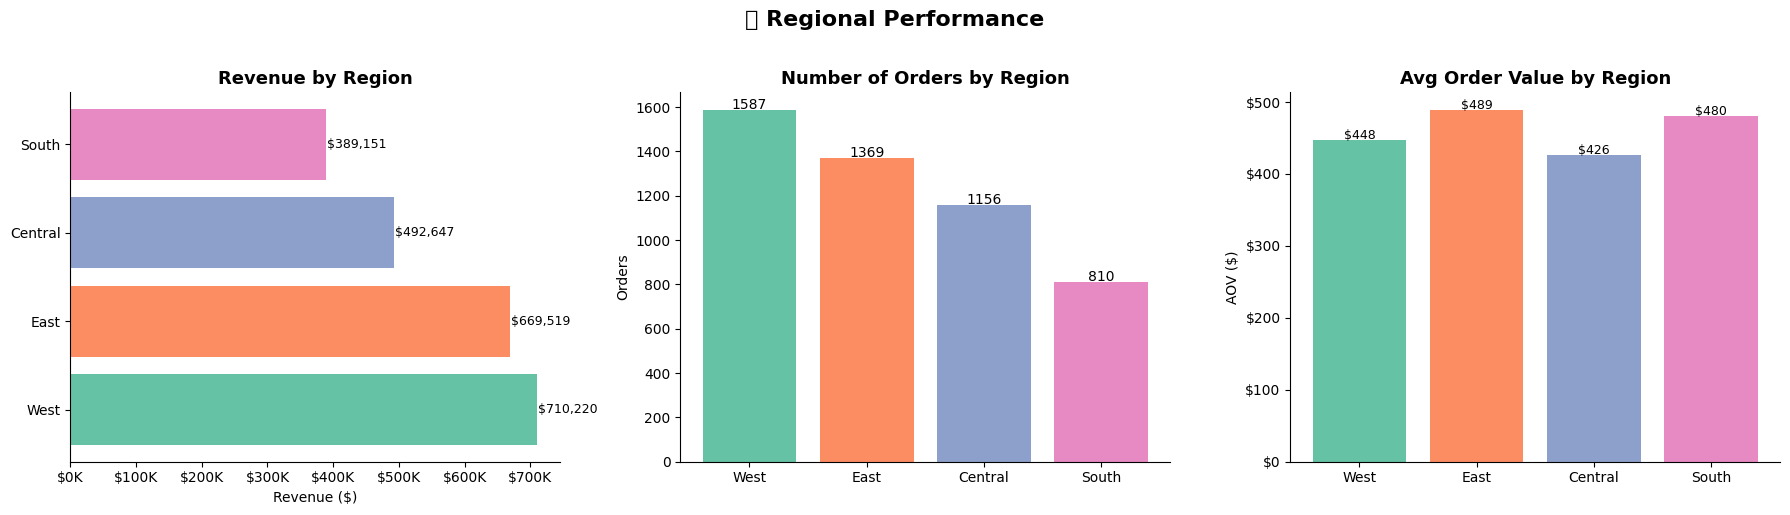

 Region     Revenue  Orders  Customers        AOV
   West 710219.6845    1587        681 447.523431
   East 669518.7260    1369        669 489.056776
Central 492646.9132    1156        626 426.165150
  South 389151.4590     810        509 480.433900


In [26]:
# Regional Performance

region_sales = (df.groupby('Region')
                  .agg(Revenue=('Sales','sum'),
                       Orders=('Order_ID','nunique'),
                       Customers=('Customer_ID','nunique'))
                  .sort_values('Revenue', ascending=False)
                  .reset_index())

region_sales['AOV'] = region_sales['Revenue'] / region_sales['Orders']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Chart 1: Revenue by Region
bars = axes[0].barh(region_sales['Region'], region_sales['Revenue'],
                    color=sns.color_palette("Set2", len(region_sales)))
axes[0].set_title('Revenue by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
for bar, val in zip(bars, region_sales['Revenue']):
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

# ── Chart 2: Orders by Region
axes[1].bar(region_sales['Region'], region_sales['Orders'],
            color=sns.color_palette("Set2", len(region_sales)))
axes[1].set_title('Number of Orders by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Orders')
for i, (_, row) in enumerate(region_sales.iterrows()):
    axes[1].text(i, row['Orders'] + 5, str(row['Orders']), ha='center', fontsize=10)

# ── Chart 3: AOV by Region
axes[2].bar(region_sales['Region'], region_sales['AOV'],
            color=sns.color_palette("Set2", len(region_sales)))
axes[2].set_title('Avg Order Value by Region', fontsize=13, fontweight='bold')
axes[2].set_ylabel('AOV ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (_, row) in enumerate(region_sales.iterrows()):
    axes[2].text(i, row['AOV'] + 1, f"${row['AOV']:,.0f}", ha='center', fontsize=9)

plt.suptitle('🗺️ Regional Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(region_sales.to_string(index=False))

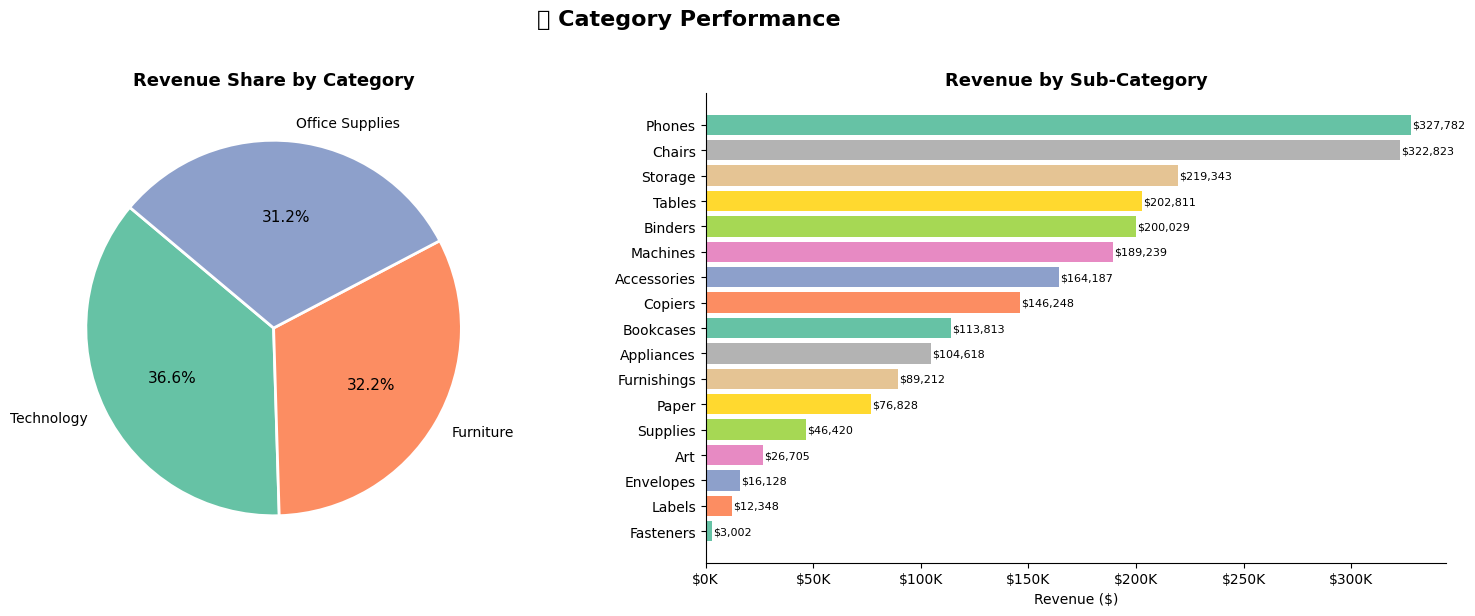

In [27]:
# Category & Sub-Category Analysis

cat_sales    = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
subcat_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Category Pie
wedges, texts, autotexts = axes[0].pie(
    cat_sales, labels=cat_sales.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette("Set2", len(cat_sales)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
axes[0].set_title('Revenue Share by Category', fontsize=13, fontweight='bold')

# ── Chart 2: Sub-Category Horizontal Bar
colors_sc = sns.color_palette("Set2", len(subcat_sales))
bars = axes[1].barh(subcat_sales.index[::-1], subcat_sales.values[::-1], color=colors_sc)
axes[1].set_title('Revenue by Sub-Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
for bar, val in zip(bars, subcat_sales.values[::-1]):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=8)

plt.suptitle('🗂️ Category Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

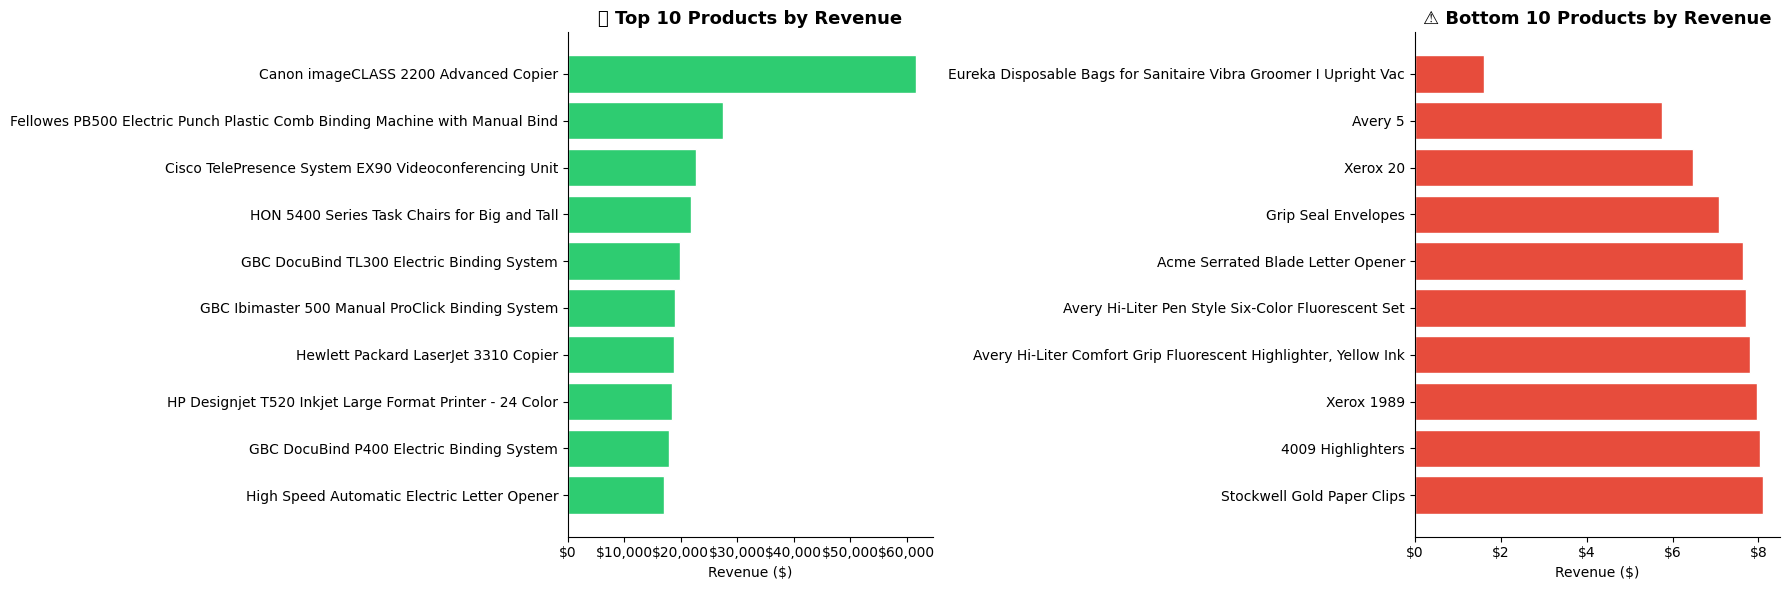

In [28]:
# Top & Bottom Products

product_sales = (df.groupby('Product_Name')['Sales']
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())

top10    = product_sales.head(10)
bottom10 = product_sales.tail(10).sort_values('Sales')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Top 10
axes[0].barh(top10['Product_Name'], top10['Sales'], color='#2ecc71', edgecolor='white')
axes[0].set_title('🏆 Top 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].invert_yaxis()

# ── Bottom 10
axes[1].barh(bottom10['Product_Name'], bottom10['Sales'], color='#e74c3c', edgecolor='white')
axes[1].set_title('⚠️ Bottom 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

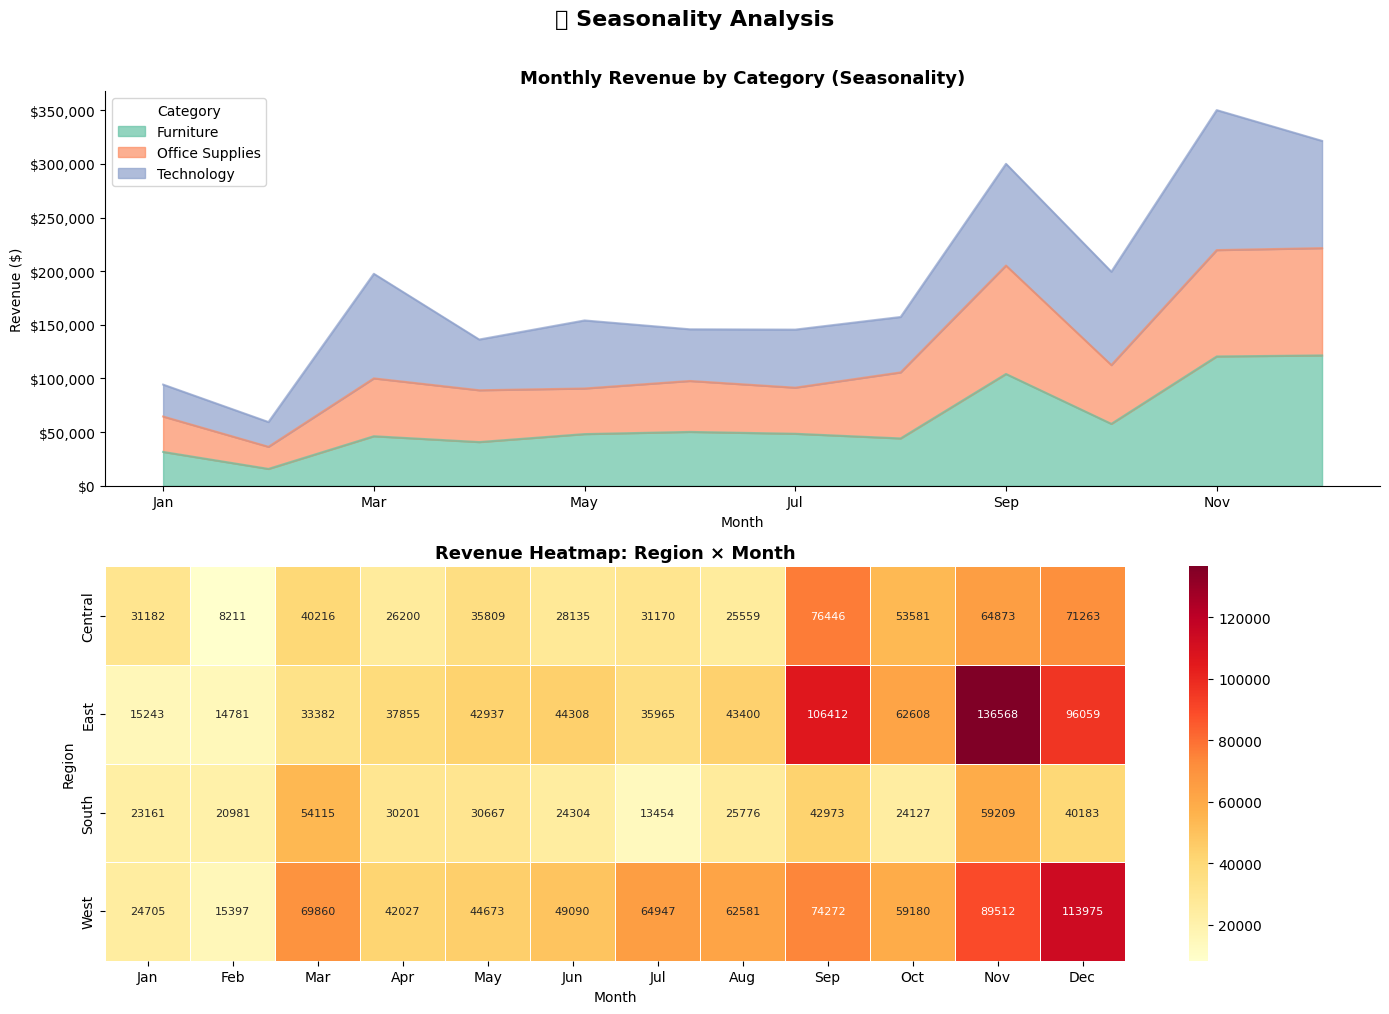

In [29]:
# Seasonality Analysis

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

season_cat = (df.groupby(['Month_Name', 'Category'])['Sales']
                .sum()
                .reset_index())
season_cat['Month_Name'] = pd.Categorical(season_cat['Month_Name'],
                                           categories=month_order, ordered=True)
season_cat = season_cat.sort_values('Month_Name')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Chart 1: Monthly revenue by category (stacked area)
pivot = season_cat.pivot(index='Month_Name', columns='Category', values='Sales').fillna(0)
pivot.plot(kind='area', ax=axes[0], alpha=0.7,
           color=sns.color_palette("Set2", 3))
axes[0].set_title('Monthly Revenue by Category (Seasonality)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(title='Category', loc='upper left')

# ── Chart 2: Heatmap — Region × Month
heat_data = (df.groupby(['Region', 'Month_Name'])['Sales']
               .sum()
               .reset_index())
heat_data['Month_Name'] = pd.Categorical(heat_data['Month_Name'],
                                          categories=month_order, ordered=True)
heat_pivot = heat_data.pivot(index='Region', columns='Month_Name', values='Sales').fillna(0)
heat_pivot = heat_pivot[month_order]

sns.heatmap(heat_pivot, ax=axes[1], annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Revenue Heatmap: Region × Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Region')

plt.suptitle('📆 Seasonality Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

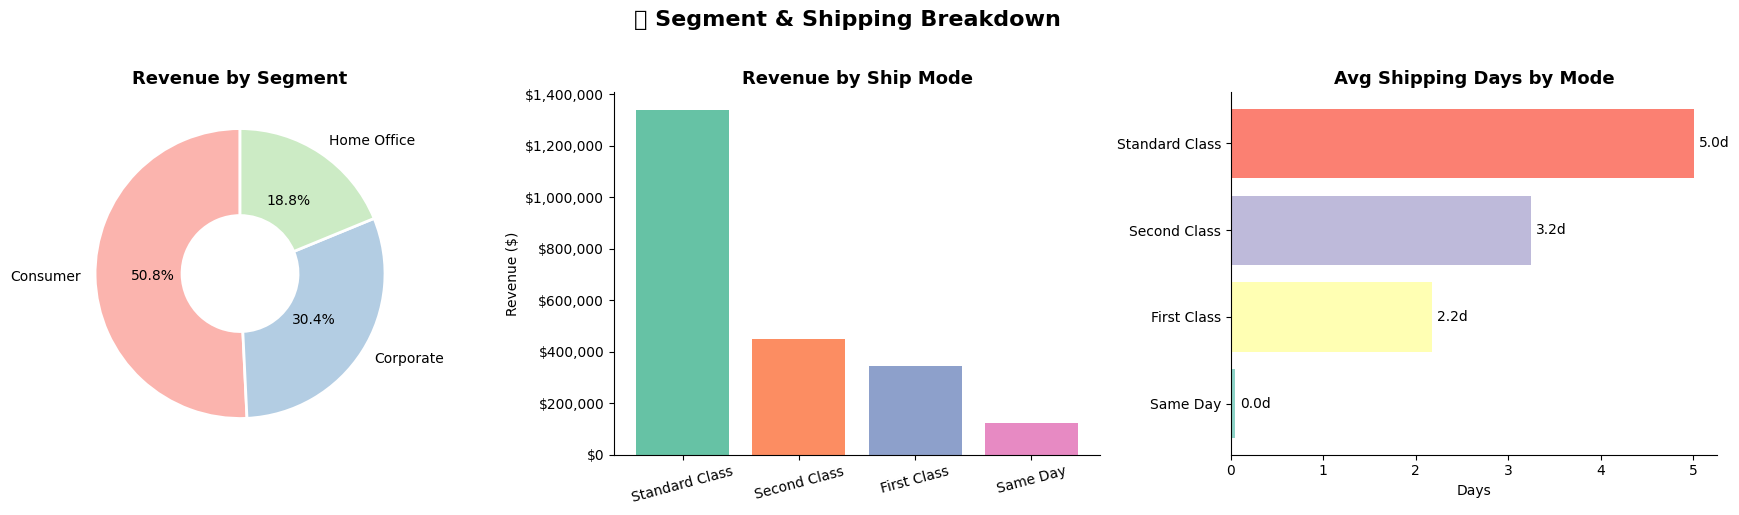

In [30]:
# Segment & Shipping Analysis

seg_sales  = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
ship_sales = df.groupby('Ship_Mode')['Sales'].sum().sort_values(ascending=False)
ship_days  = df.groupby('Ship_Mode')['Ship_Days'].mean().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Segment Revenue Donut
wedges, texts, autotexts = axes[0].pie(
    seg_sales, labels=seg_sales.index, autopct='%1.1f%%',
    startangle=90, colors=sns.color_palette("Pastel1", len(seg_sales)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6}
)
axes[0].set_title('Revenue by Segment', fontsize=13, fontweight='bold')

# ── Ship Mode Revenue
axes[1].bar(ship_sales.index, ship_sales.values,
            color=sns.color_palette("Set2", len(ship_sales)))
axes[1].set_title('Revenue by Ship Mode', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)

# ── Avg Ship Days
axes[2].barh(ship_days.index, ship_days.values,
             color=sns.color_palette("Set3", len(ship_days)))
axes[2].set_title('Avg Shipping Days by Mode', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Days')
for i, (mode, days) in enumerate(ship_days.items()):
    axes[2].text(days + 0.05, i, f'{days:.1f}d', va='center', fontsize=10)

plt.suptitle('👥 Segment & Shipping Breakdown', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Final Summary Table

summary = df.groupby(['Region', 'Category']).agg(
    Revenue     = ('Sales', 'sum'),
    Orders      = ('Order_ID', 'nunique'),
    Customers   = ('Customer_ID', 'nunique'),
    Avg_Sale    = ('Sales', 'mean')
).round(2).reset_index()

summary['Revenue_K'] = (summary['Revenue'] / 1000).round(1).astype(str) + 'K'

print("        FINAL SUMMARY: Region × Category Performance")
print(summary[['Region','Category','Revenue_K','Orders','Customers','Avg_Sale']]
      .to_string(index=False))
print(f"\n Analysis Complete | Total Revenue: ${df['Sales'].sum():,.0f} | Orders: {df['Order_ID'].nunique():,}")

        FINAL SUMMARY: Region × Category Performance
 Region        Category Revenue_K  Orders  Customers  Avg_Sale
Central       Furniture    160.3K     393        312    341.10
Central Office Supplies    163.6K     865        537    116.93
Central      Technology    168.7K     348        290    413.58
   East       Furniture    206.5K     480        368    349.34
   East Office Supplies    199.9K    1048        605    119.94
   East      Technology    263.1K     436        349    499.27
  South       Furniture    116.5K     272        237    357.46
  South Office Supplies    124.4K     613        421    126.58
  South      Technology    148.2K     252        217    512.79
   West       Furniture    245.3K     582        416    355.06
   West Office Supplies    217.5K    1150        600    116.92
   West      Technology    247.4K     483        359    420.04

 Analysis Complete | Total Revenue: $2,261,537 | Orders: 4,922
